In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [4]:
db = pd.read_csv("set1.csv")
db

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


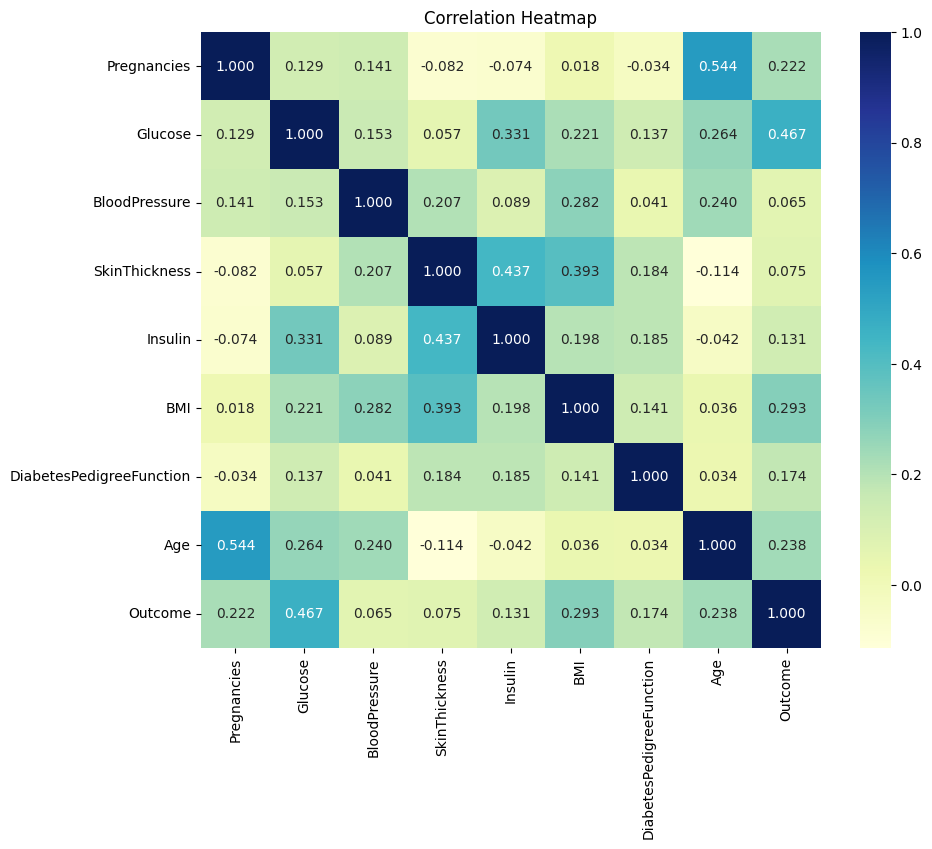

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    db.corr(),
    annot=True,
    fmt=".3f",
    cmap="YlGnBu"
)
plt.title("Correlation Heatmap")
plt.show()


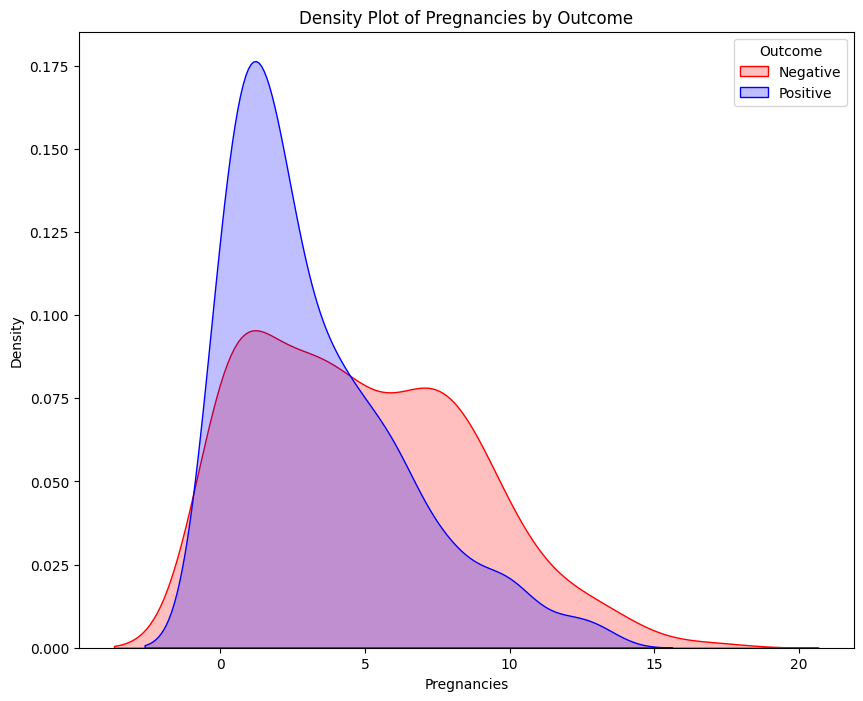

In [6]:
plt.figure(figsize=(10, 8))

sns.kdeplot(
    data=db,
    x="Pregnancies",
    hue="Outcome",
    fill=True,
    palette={1: "red", 0: "blue"},
    common_norm=False
)

plt.xlabel("Pregnancies")
plt.ylabel("Density")
plt.title("Density Plot of Pregnancies by Outcome")
plt.legend(title="Outcome", labels=["Negative", "Positive"])
plt.show()


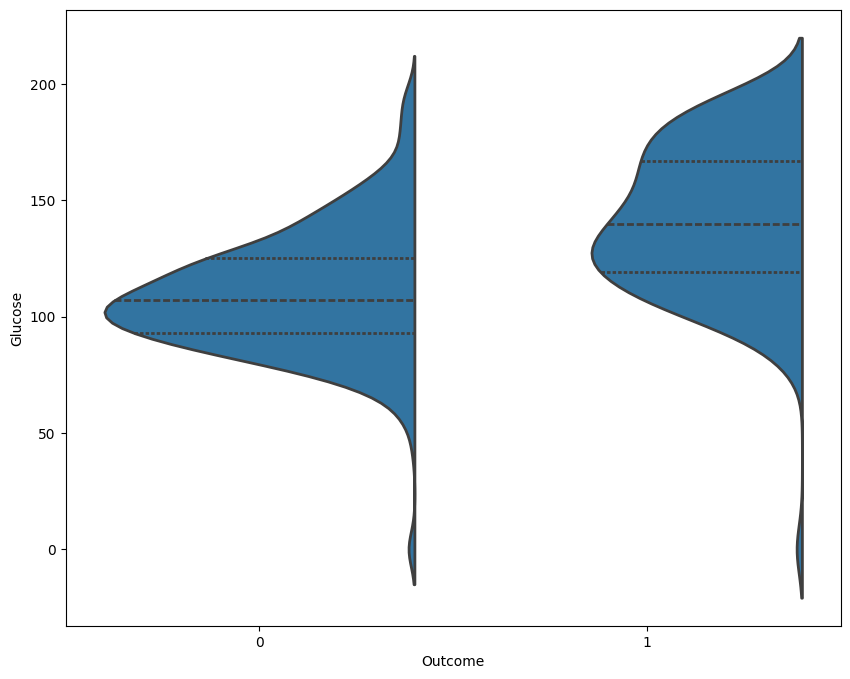

In [7]:
plt.figure(figsize=(10, 8))

sns.violinplot(
    data=db,
    x="Outcome",
    y="Glucose",
    split=True,
    linewidth=2,
    inner="quart"
)

plt.show()

    

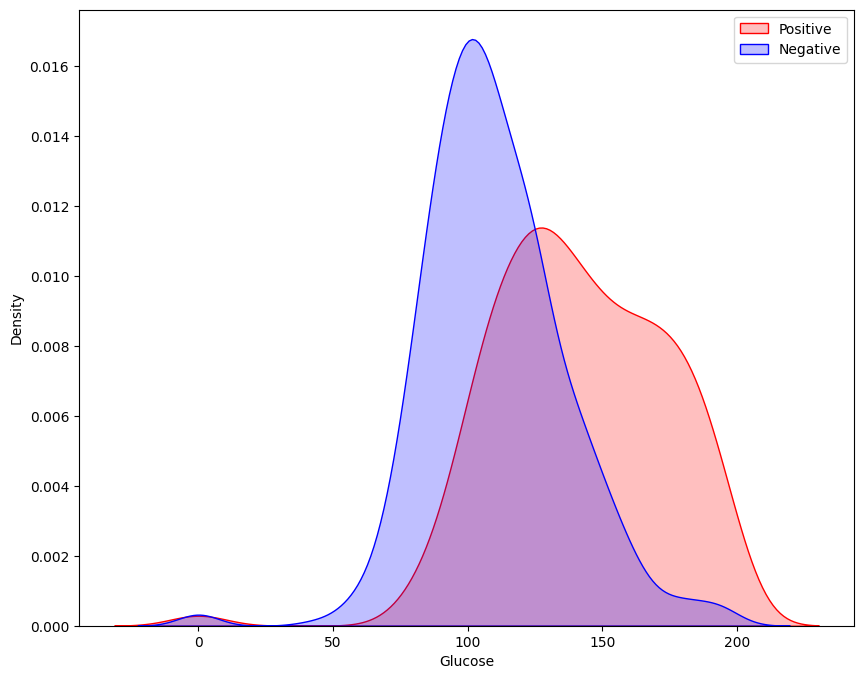

In [8]:
# Exploring Glucose and target variables
plt.figure(figsize = (10,8))

# Plotting Density function graph of the glucose and target variables
kde = sns.kdeplot(db['Glucose'][db['Outcome']==1], 
                  color = "Red",
                  fill=True
                 )
kde = sns.kdeplot(db['Glucose'][db['Outcome']==0],
                  color = "Blue",
                  fill=True
                 )

kde.set_xlabel('Glucose')
kde.set_ylabel("Density")
kde.legend(["Positive","Negative"])



In [9]:
# Glucose
db["Glucose"] = db["Glucose"].replace(0,db["Glucose"].median())
#Insulin
db["Insulin"] = db["Insulin"].replace(0,db["Insulin"].median())
#SkinThickness
db["SkinThickness"] = db["SkinThickness"].replace(0,db["SkinThickness"].mean())
#BMI
db["BMI"] = db["BMI"].replace(0,db["BMI"].mean())
db

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.000000,30.5,33.6,0.627,50,1
1,1,85,66,29.000000,30.5,26.6,0.351,31,0
2,8,183,64,20.536458,30.5,23.3,0.672,32,1
3,1,89,66,23.000000,94.0,28.1,0.167,21,0
4,0,137,40,35.000000,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48.000000,180.0,32.9,0.171,63,0
764,2,122,70,27.000000,30.5,36.8,0.340,27,0
765,5,121,72,23.000000,112.0,26.2,0.245,30,0
766,1,126,60,20.536458,30.5,30.1,0.349,47,1


In [10]:
X = db.drop(["Outcome"],axis = 1)
Y = db["Outcome"]

In [11]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35.000000,30.5,33.6,0.627,50
1,1,85,66,29.000000,30.5,26.6,0.351,31
2,8,183,64,20.536458,30.5,23.3,0.672,32
3,1,89,66,23.000000,94.0,28.1,0.167,21
4,0,137,40,35.000000,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48.000000,180.0,32.9,0.171,63
764,2,122,70,27.000000,30.5,36.8,0.340,27
765,5,121,72,23.000000,112.0,26.2,0.245,30
766,1,126,60,20.536458,30.5,30.1,0.349,47


In [12]:
Y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [ ]:
!pip install scikit-learn


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
xtrain , xtest , ytrain , ytest = train_test_split(X , Y ,test_size= 0.44 , random_state = 60)

In [ ]:
xtrain

In [ ]:
ytrain

In [ ]:
xtest

In [ ]:
ytest

In [ ]:

from sklearn.neighbors import KNeighborsClassifier


In [ ]:


train_acc = []
test_acc = []

for nn in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=nn)
    knn.fit(xtrain, ytrain)
    
    train_acc.append(knn.score(xtrain, ytrain))
    test_acc.append(knn.score(xtest, ytest))     

plt.plot(range(1, 11), train_acc, label="Training accuracy")
plt.plot(range(1, 11), test_acc, label="Testing accuracy")

plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.legend()  
plt.show()


In [ ]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(xtrain, ytrain)

print(knn.score(xtrain, ytrain), ": Training accuracy")
print(knn.score(xtest, ytest), ": Test accuracy")


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(xtrain, ytrain)

print(dt.score(xtrain, ytrain), ": Training accuracy")
print(dt.score(xtest, ytest), ": Test accuracy")


In [ ]:
dt1 = DecisionTreeClassifier(random_state = 0,
                            max_depth=10)
dt1.fit(xtrain, ytrain)

print(dt1.score(xtrain, ytrain), ": Training accuracy")
print(dt1.score(xtest, ytest), ": Test accuracy")


In [ ]:
from sklearn.neural_network import MLPClassifier
m = MLPClassifier(random_state = 42)
m.fit(xtrain, ytrain)

print(m.score(xtrain, ytrain), ": Training accuracy")
print(m.score(xtest, ytest), ": Test accuracy")

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier


s = StandardScaler()
xtrain_s = s.fit_transform(xtrain)
xtest_s = s.transform(xtest)


m = MLPClassifier(random_state=0)
m.fit(xtrain_s, ytrain)


print(m.score(xtrain_s, ytrain), ": Training accuracy")
print(m.score(xtest_s, ytest), ": Test accuracy")


0.8162790697674419 : Training accuracy
0.7514792899408284 : Test accuracy


C:\Users\priya\miniconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
